#Импорт библиотек и загрузка датасетов

In [41]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)

In [42]:
files = {
    "yellow": "D:/Pet_projekts/realty/realty/y.csv",
    "red": "D:/Pet_projekts/realty/realty/r.csv",

}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

dfy = dfs["yellow"]
dfr = dfs["red"]

In [43]:
dfy = dfy.drop(columns=["uuid","code","url","title","price_currency","storey","storeys","contact_name","contact_phones","photo","description", "town_name", "state_region", "state_district"], errors="ignore")

In [44]:
dfr = dfr.drop(columns=["resale","photo","id","url", "latitude", "longitude"], errors="ignore") #сразу удаляем лишние колонки (внутренние id, ссылки, фото, персональные данные)

In [45]:
dfy.head(1)

,price,price_usd,price_byn,price_per_m2,rooms,area_total,area_living,area_kitchen,address,street_name,house_number,metro_station,metro_time,building_year,wall_material,repair_state,agency_name,created_at,updated_at
0,257800,85150,257800,11017,1,23.4,19.7,NaN,Минск Жореса Алфёрова ул. 12,Жореса Алфёрова ул.,12.0,Аэродромная (2024),NaN,2023,NaN,2.0,Бир Бай,2026-08-28T17:37:08+03:00,2026-09-17T10:01:47+03:00


In [46]:
dfr.head(1)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,seller_type,building_type,building_year,created_at,last_time_up,auction_bid_amount,auction_bid_currency
0,342570.0,BYN,112999.74,342570.0,1,10,10,42.4,18.6,9.3,"Минск, Горецкого ул. 34","Минск, Горецкого ул. 34",agent,панельный,2015.0,2026-09-16T19:25:00+03:00,2026-09-25T14:01:34+03:00,3.0,BYN


#EDA - Разведывательный анализ данных

## Первый датасет

In [47]:
dfy.isna().sum() #пропущенные значения в таблице

price               0
price_usd           0
price_byn           0
price_per_m2        0
rooms               0
area_total          0
area_living      1369
area_kitchen     2924
address             0
street_name         0
house_number       60
metro_station    1735
metro_time       3079
building_year       0
wall_material    3675
repair_state     1468
agency_name       353
created_at          0
updated_at          0
dtype: int64

In [48]:
dfy = dfy.drop(columns=['wall_material', 'metro_time']) # дополнительно удаляем колонки с большим количеством незаполненных значений

In [49]:
print('Дубликатов =', dfy.duplicated().sum())

Дубликатов = 4


In [50]:
dfy = dfy.drop_duplicates() # удаляем дубликаты

In [51]:
dfy.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
Index: 3671 entries, 0 to 3674
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          3671 non-null   int64  
 1   price_usd      3671 non-null   int64  
 2   price_byn      3671 non-null   int64  
 3   price_per_m2   3671 non-null   int64  
 4   rooms          3671 non-null   int64  
 5   area_total     3671 non-null   float64
 6   area_living    2306 non-null   float64
 7   area_kitchen   751 non-null    float64
 8   address        3671 non-null   str    
 9   street_name    3671 non-null   str    
 10  house_number   3611 non-null   float64
 11  metro_station  1940 non-null   str    
 12  building_year  3671 non-null   int64  
 13  repair_state   2207 non-null   float64
 14  agency_name    3318 non-null   str    
 15  created_at     3671 non-null   str    
 16  updated_at     3671 non-null   str    
dtypes: float64(5), int64(6), str(6)
memory usage: 1.1 MB


In [52]:
cat_columnsy = [] # создаем пустой список для имен колонок категориальных данных
num_columnsy = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfy.columns: # смотрим на все колонки в датафрейме
    if (dfy[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsy +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsy +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsy, '\n Число столблцов = ',len(cat_columnsy))

print('Числовые данные:\t ',  num_columnsy, '\n Число столблцов = ',len(num_columnsy))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['price', 'price_usd', 'price_byn', 'price_per_m2', 'rooms', 'area_total', 'area_living', 'area_kitchen', 'address', 'street_name', 'house_number', 'metro_station', 'building_year', 'repair_state', 'agency_name', 'created_at', 'updated_at'] 
 Число столблцов =  17


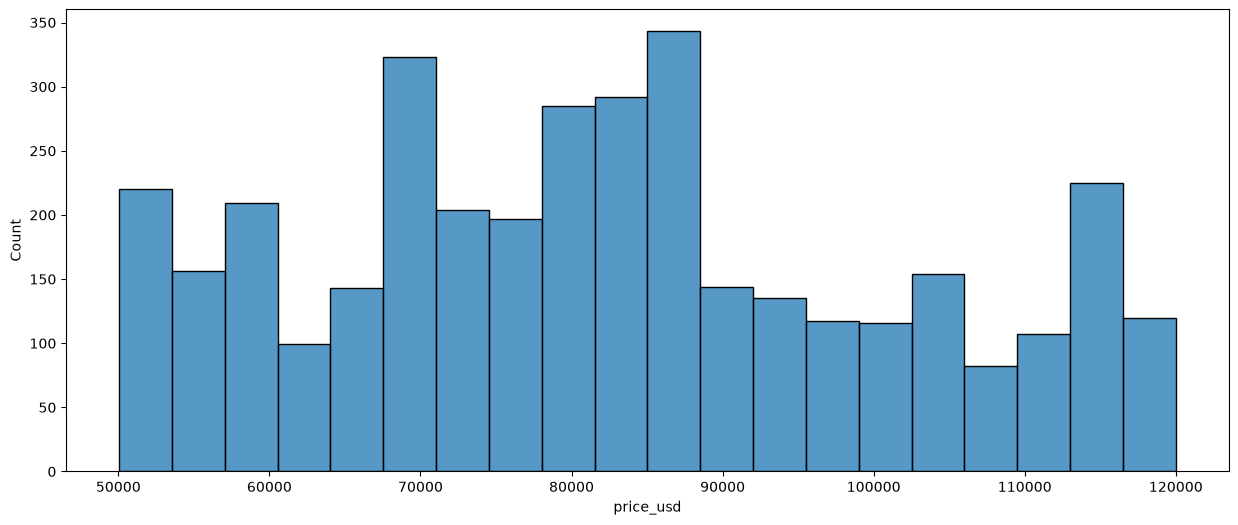

In [53]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfy, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

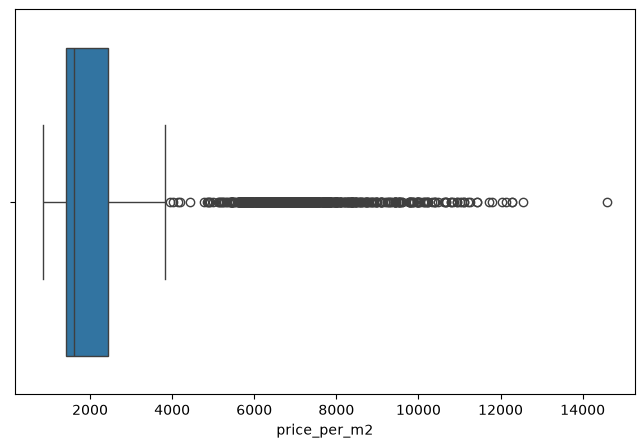

In [54]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfy, x="price_per_m2")
plt.show()

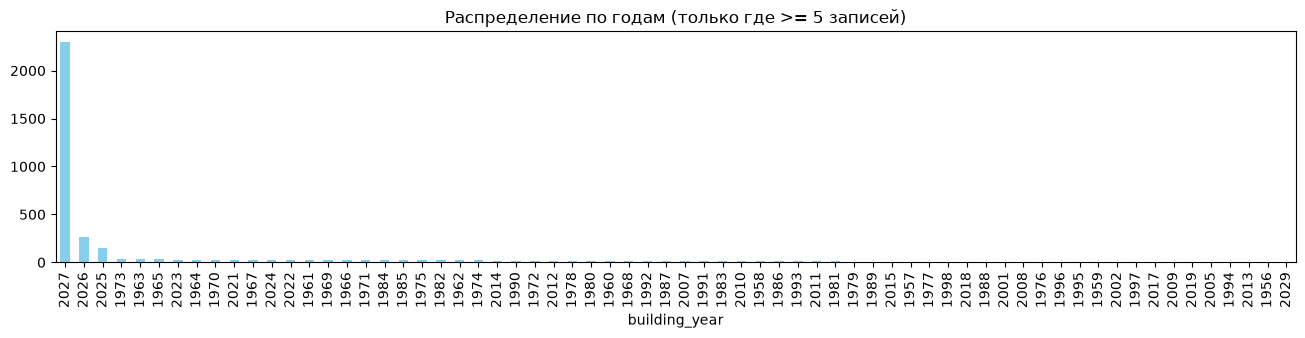

In [55]:
# График распределения по годам постройки

counts = dfy['building_year'].value_counts()

counts_filtered = counts[counts >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (только где >= 5 записей)')
plt.show()

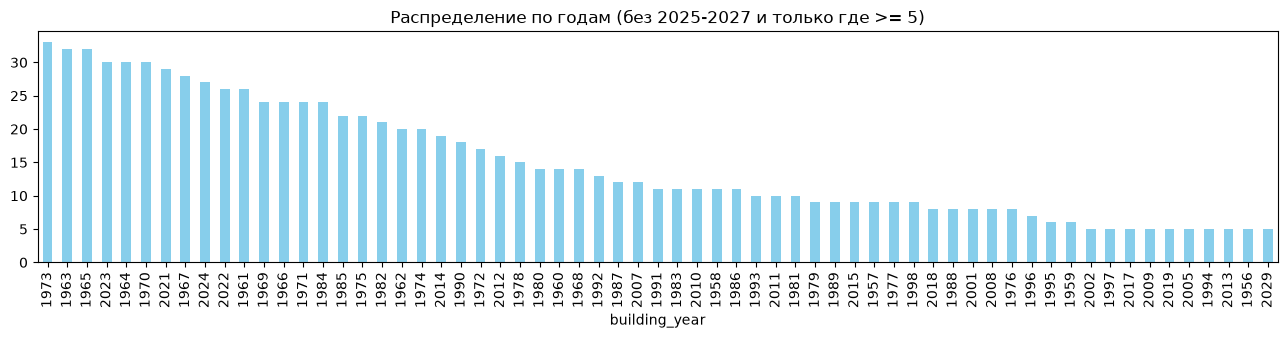

In [56]:
# Убираем новостройки 2025-27 гг

counts = dfy['building_year'].value_counts()

counts_filtered = counts[~counts.index.isin([2025, 2026, 2027])]
counts_filtered = counts_filtered[counts_filtered >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (без 2025-2027 и только где >= 5)')
plt.show()

In [57]:
#Итоговое количество объектов после чистки

total_objects = counts_filtered.sum()

print("Сколько объектов попало (суммарно):", total_objects)

Сколько объектов попало (суммарно): 936


In [58]:
# Распределение по агенствам

res = (dfy['agency_name']
       .value_counts(dropna=False)
       .reset_index(name='count')
       .rename(columns={'index': 'agency_name'}))

pd.set_option('display.max_rows', None)
print(res)


                                     agency_name  count
0                                        Бир Бай   1355
1       Международная риэлтерская компания ЭТАЖИ   1203
2                                            NaN    353
3          Агентство недвижимости «Твоя столица»     54
4                 Агентство недвижимости Мариэлт     46
5                              Бриллиантовый лев     44
6                                  Фаттория Плюс     41
7                                Квадратный метр     34
8                                    АН Фаттория     32
9                            ТВОЯ СТОЛИЦАконсалт     31
10                                       Мольнар     24
11                                      7 этажей     24
12                                        Алькор     22
13                           Резалт Недвижимость     22
14                            Альфа-Недвижимость     21
15                     Риэлтерский центр Столицы     17
16       Центр международной недвижимости Моя 7Я

In [59]:
# Меняем содержание столбца агенства (все агенты теперь не делятся по кампаниям и появляется собственник)

dfy["agency_name"] = np.where(dfy["agency_name"].isna(), "owner", "agent")

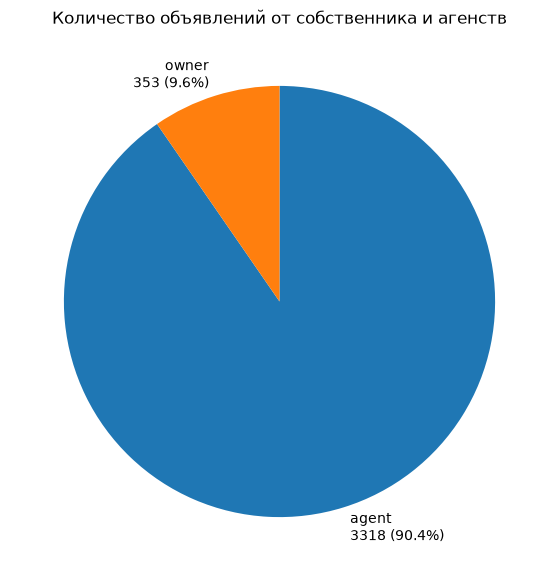

In [60]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfy["agency_name"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("Количество объявлений от собственника и агенств")
plt.show()

##Второй датасет

In [61]:
dfr.isna().sum() #пропущенные значения в таблице

price_amount               0
price_currency             0
price_usd                  0
price_byn                  0
number_of_rooms            0
floor                      0
number_of_floors           0
area_total                 0
area_living                0
area_kitchen             443
address                  116
user_address               0
seller_type                0
building_type              9
building_year              9
created_at                 0
last_time_up               0
auction_bid_amount      1613
auction_bid_currency    1613
dtype: int64

In [62]:
dfr = dfr.drop(columns=['auction_bid_amount', 'auction_bid_currency']) # дополнительно удаляем колонки с большим количеством незаполненных значений

In [63]:
print('Дубликатов =', dfr.duplicated().sum())

Дубликатов = 0


In [68]:
#dfr = dfy.drop_duplicates() # удаляем дубликаты

In [64]:
dfr.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_amount      1620 non-null   float64
 1   price_currency    1620 non-null   str    
 2   price_usd         1620 non-null   float64
 3   price_byn         1620 non-null   float64
 4   number_of_rooms   1620 non-null   int64  
 5   floor             1620 non-null   int64  
 6   number_of_floors  1620 non-null   int64  
 7   area_total        1620 non-null   float64
 8   area_living       1620 non-null   float64
 9   area_kitchen      1177 non-null   float64
 10  address           1504 non-null   str    
 11  user_address      1620 non-null   str    
 12  seller_type       1620 non-null   str    
 13  building_type     1611 non-null   str    
 14  building_year     1611 non-null   float64
 15  created_at        1620 non-null   str    
 16  last_time_up      1620 non-null   str    
dtypes: flo

In [65]:
cat_columnsr = [] # создаем пустой список для имен колонок категориальных данных
num_columnsr = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfr.columns: # смотрим на все колонки в датафрейме
    if (dfr[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsr +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsr +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsr, '\n Число столблцов = ',len(cat_columnsr))

print('Числовые данные:\t ',  num_columnsr, '\n Число столблцов = ',len(num_columnsr))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['price_amount', 'price_currency', 'price_usd', 'price_byn', 'number_of_rooms', 'floor', 'number_of_floors', 'area_total', 'area_living', 'area_kitchen', 'address', 'user_address', 'seller_type', 'building_type', 'building_year', 'created_at', 'last_time_up'] 
 Число столблцов =  17


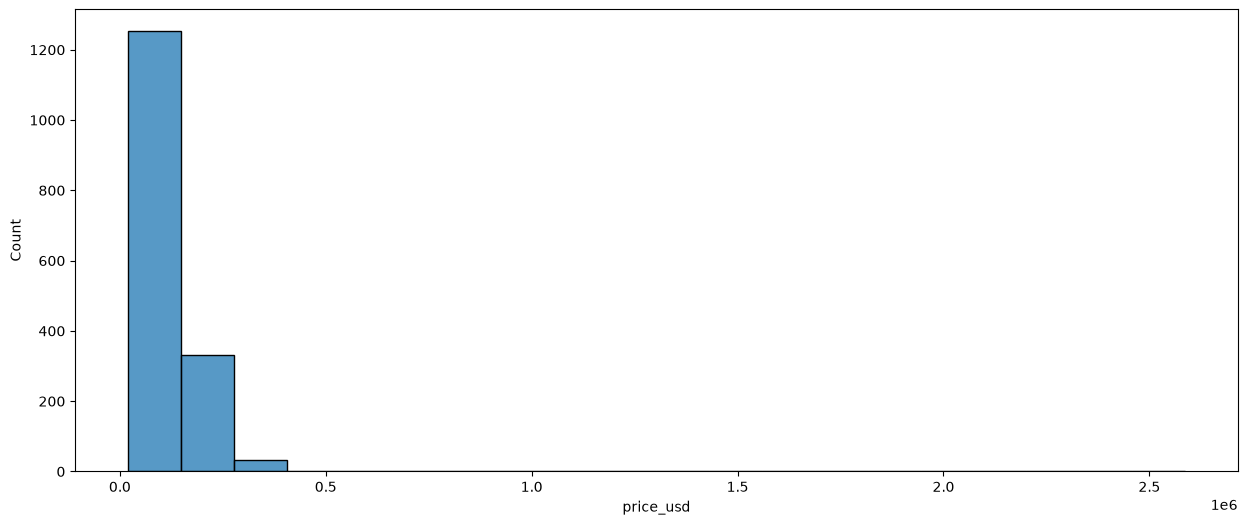

In [66]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfr, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

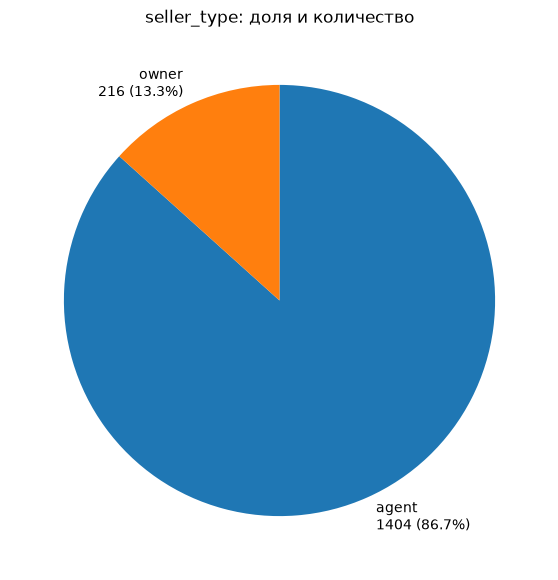

In [67]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfr["seller_type"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("seller_type: доля и количество")
plt.show()

In [68]:
# в данном датасете нет колонки "цена за м2", создадим её

dfr["price_per_m2"] = dfr["price_usd"] / dfr["area_total"].replace(0, np.nan)

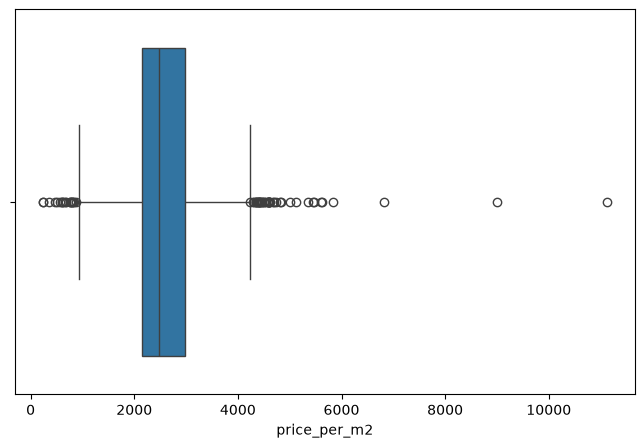

In [69]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfr, x="price_per_m2")
plt.show()

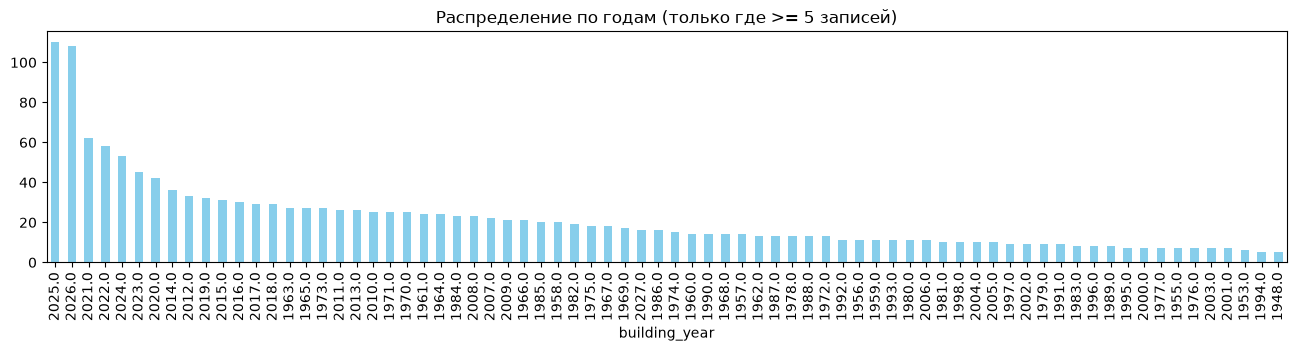

In [70]:
# График распределения по годам постройки

counts = dfr['building_year'].value_counts()

counts_filtered = counts[counts >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (только где >= 5 записей)')
plt.show()

In [79]:
col = "building_year"

dfr[col] = pd.to_numeric(dfr[col], errors="coerce")
dfr = dfr.dropna(subset=[col])
dfr[col] = dfr[col].astype(int)

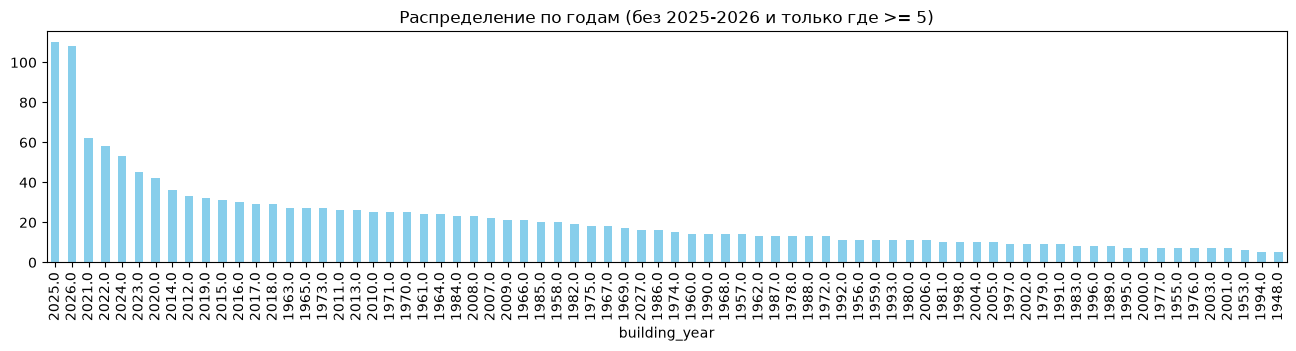

In [80]:
# Убираем новостройки 2025-26 гг

counts = dfr['building_year'].value_counts()

counts_filteredr = counts[~counts.index.isin([2025, 2026])]
counts_filteredr = counts_filteredr[counts_filteredr >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (без 2025-2026 и только где >= 5)')
plt.show()

In [81]:
total_objectsr = counts_filtered.sum()

print("Сколько объектов попало (суммарно):", total_objectsr)

Сколько объектов попало (суммарно): 1575


#Подготовка к сопоставлению

In [82]:
dfy.head(2)

,price,price_usd,price_byn,price_per_m2,rooms,area_total,area_living,area_kitchen,address,street_name,house_number,metro_station,building_year,repair_state,agency_name,created_at,updated_at
0,257800,85150,257800,11017,1,23.4,19.7,NaN,Минск Жореса Алфёрова ул. 12,Жореса Алфёрова ул.,12.0,Аэродромная (2024),2023,2.0,agent,2026-08-28T17:37:08+03:00,2026-09-17T10:01:47+03:00
1,110250,110250,333793,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,Лосика ул.,47.0,NaN,2026,8.0,owner,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00


In [83]:
dfr.head(2)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,seller_type,building_type,building_year,created_at,last_time_up,price_per_m2
0,342570.0,BYN,112999.74,342570.00,1,10,10,42.4,18.6,9.3,"Минск, Горецкого ул. 34","Минск, Горецкого ул. 34",agent,панельный,2015,2026-09-16T19:25:00+03:00,2026-09-25T14:01:34+03:00,2665.088208
1,114600.0,USD,114600.00,347421.36,2,6,10,53.3,31.8,9.2,"Минск, улица Сергея Есенина, 117","Минск, улица Сергея Есенина, 117",owner,блочный,1992,2026-09-14T20:27:53+03:00,2026-09-27T12:57:51+03:00,2150.093809


In [84]:
# Удаляем столбцы, которых нет в одном из датасетов

dfy = dfy.drop(columns=['price', 'price_byn', 'street_name', 'house_number', 'repair_state', 'metro_station'])
dfr = dfr.drop(columns=['price_amount', 'price_currency', 'price_byn'])

In [88]:
# переименовываем колонки

dfr = dfr.rename(columns={
    "number_of_rooms": "rooms",
    "seller_type": "agency_name",
    "last_time_up": "updated_at"
})

# задаём новый порядок
new_order = [
    "price_usd",
    "price_per_m2",
    "rooms",
    "area_total",
    "area_living",
    "area_kitchen",
    "address",
    "user_address",
    'building_year',
    "agency_name",
    "created_at",
    "updated_at"
]

# переставляем колонки
dfr = dfr[new_order]

Получили два одинаковых датасета по внешнему виду

In [89]:
dfy.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,building_year,agency_name,created_at,updated_at
0,85150,11017,1,23.4,19.7,NaN,Минск Жореса Алфёрова ул. 12,2023,agent,2026-08-28T17:37:08+03:00,2026-09-17T10:01:47+03:00


In [90]:
dfr.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,user_address,building_year,agency_name,created_at,updated_at
0,112999.74,2665.088208,1,42.4,18.6,9.3,"Минск, Горецкого ул. 34","Минск, Горецкого ул. 34",2015,agent,2026-09-16T19:25:00+03:00,2026-09-25T14:01:34+03:00


In [91]:
# Разбиваем колонку адрес на две с улицей и номером дома

extracted = dfy['address'].str.extract(r'Минск\s+(.+?)\s+ул\.\s+(\d+)')

dfy['street'] = extracted[0]
dfy['number'] = extracted[1].astype('Int64')

print(dfy)

      price_usd  price_per_m2  rooms  area_total  area_living  area_kitchen  \
0         85150         11017      1       23.40       19.700           NaN   
1        110250          2250      1       49.00       49.000           NaN   
2         78115          5267      2       44.90       36.800           NaN   
3         81107          7464      1       32.90       17.000         7.200   
4         83900          1814      2       46.25       30.600           NaN   
5         94134          9375      1       30.40       20.600         4.900   
6        105694          7547      2       42.40       27.300           NaN   
7        115000          2527      1       45.50       38.300           NaN   
8        110318          6122      2       54.56       31.160         9.550   
9        114500          2093      2       54.70       29.100         8.800   
10        72300          2317      1       31.20       15.400         7.800   
11        76959          7979      1       29.20    

In [92]:
# 1. Чистим запятые и лишние пробелы
dfr['address_clean'] = (
    dfr['user_address']
    .str.replace(',', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# 2. Более гибкое извлечение
def extract_street_number(addr):
    if pd.isna(addr):
        return pd.Series([None, None])
    
    # Ищем паттерн: (улица/ул./вуліца) + название улицы + номер
    match = re.search(
        r'(?:улица|ул\.?|вуліца)\s+(.+?)\s+(\d+[А-Яа-яA-Za-z]*\s*[к/]?\s*\d*[А-Яа-яA-Za-z]*)',
        addr,
        flags=re.IGNORECASE
    )
    
    if match:
        street = match.group(1).strip()
        number = match.group(2).strip()
        return pd.Series([street, number])
    
    # Запасной вариант: просто берём последние 1-2 слова как номер, остальное как улицу
    parts = addr.split()
    if len(parts) >= 2 and re.search(r'\d', parts[-1]):
        number = parts[-1]
        street = ' '.join(parts[:-1])
        # Убираем "Минск", "Minsk", "Беларусь" если они остались
        street = re.sub(r'^(Минск|Minsk|Беларусь)\s+', '', street, flags=re.IGNORECASE)
        return pd.Series([street, number])
    
    return pd.Series([None, None])

dfr[['street', 'number']] = dfr['address_clean'].apply(extract_street_number)

# Смотрим результат
print(dfr[['address', 'street', 'number']].head(15))
print("\nКоличество распознанных строк:", dfr['street'].notna().sum())
print("Не распознанные:")
print(dfr[dfr['street'].isna()][['address']].head(10))

                                              address  \
0                             Минск, Горецкого ул. 34   
1                    Минск, улица Сергея Есенина, 117   
2                          Минск, Игоря Лученка ул. 5   
3                     Minsk, вуліца Міхаіла Савіцкага   
4                      Minsk, Валгаградская вуліца, 5   
5                        Минск, улица Якубовского, 38   
6                        Minsk, вуліца Матусевіча, 76   
7                Minsk, вуліца Аляксандра Воінава, 34   
8                           Минск, улица Киселёва, 11   
9         Беларусь, Минск, Героев 120 дивизии ул., 20   
10                             Минск, Братская ул. 15   
11                          Minsk, вуліца Гастэлы, 12   
12                        Минск, улица Фабрициуса, 14   
13               Минск, проспект Газеты Звязда, 14 к1   
14  Колодищанский сельский Совет, Колодищи, Лаванд...   

                                               street number  
0                       

Сопоставление

In [98]:
# 1. Подготовка данных

# Убедимся, что ключевые колонки есть и приведены к нормальному виду
for df in [dfy, dfr]:
    # Приводим числовые поля
    for col in ['rooms', 'area_total', 'area_living', 'building_year']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # street и number делаем строками и убираем лишние пробелы
    if 'street' in df.columns:
        df['street'] = df['street'].astype(str).str.strip().str.lower()
    if 'number' in df.columns:
        df['number'] = df['number'].astype(str).str.strip().str.lower()

# 2. Функция сопоставления

def find_matches(dfy, dfr):
    matches = []
    
 # Проходим по каждой строке из dfy
    for idx_y, row_y in dfy.iterrows():
        # Базовые условия (обязательные)
        mask = (
            (dfr['rooms'] == row_y['rooms']) &
            (dfr['area_total'] == row_y['area_total']) &
            (dfr['area_living'] == row_y['area_living']) &
            (dfr['building_year'] == row_y['building_year'])
        )
        
        candidates = dfr[mask]
        
        if candidates.empty:
            continue
        
        # Дополнительная проверка по street и number (если они есть)
        for idx_r, row_r in candidates.iterrows():
            street_match = True
            number_match = True
            
            # Проверяем street только если оба значения не пустые
            """if pd.notna(row_y.get('street')) and pd.notna(row_r.get('street')):
                if str(row_y['street']).strip() != '' and str(row_r['street']).strip() != '':
                    street_match = (row_y['street'] == row_r['street'])"""
            
            # Проверяем number только если оба значения не пустые
            if pd.notna(row_y.get('number')) and pd.notna(row_r.get('number')):
                if str(row_y['number']).strip() != '' and str(row_r['number']).strip() != '':
                    number_match = (row_y['number'] == row_r['number'])
            
            # Если street/number совпали (или данных недостаточно) — считаем совпадением
            if street_match and number_match:
                match_row = {
                    # Индексы для удобства
                    'dfy_index': idx_y,
                    'dfr_index': idx_r,
                    
                    # Ключевые поля
                    'rooms': row_y['rooms'],
                    'area_total': row_y['area_total'],
                    'area_living': row_y['area_living'],
                    'street_y': row_y.get('street'),
                    'number_y': row_y.get('number'),
                    'street_r': row_r.get('street'),
                    'number_r': row_r.get('number'),
                    'created_at_y': row_y.get('created_at', row_y.get('created at')),
                    'created_at_r': row_r.get('created_at', row_r.get('created at')),
                    
                    # Можно добавить другие важные колонки
                    'address_y': row_y.get('address'),
                    'address_r': row_r.get('address'),
                    'price_y': row_y.get('price_usd'),      # если есть
                    'price_r': row_r.get('price_usd'),
                }
                matches.append(match_row)
    
    return pd.DataFrame(matches)

# 3. Запускаем сопоставление

matched = find_matches(dfy, dfr)

print(f"Найдено совпадений: {len(matched)}")
print(matched.head(10))

# 4. Сохраняем в Excel

for col in ['created_at_y', 'created_at_r']:
    if col in matched.columns:
        # Превращаем в datetime
        matched[col] = pd.to_datetime(matched[col], errors='coerce')

        # Если datetime timezone-aware — делаем timezone-unaware
        # (Series.dt.tz возвращает tzinfo или None)
        if getattr(matched[col].dt, "tz", None) is not None:
            matched[col] = matched[col].dt.tz_convert(None)


matched.to_excel('matched_objects.xlsx', index=False)
print("\nФайл сохранён: matched_objects.xlsx")

Найдено совпадений: 498
   dfy_index  dfr_index  rooms  area_total  area_living         street_y  \
0          3        368      1        32.9         17.0      байкальская   
1          5        860      1        30.4         20.6   краснозвездная   
2          9        220      2        54.7         29.1           лучины   
3         10        499      1        31.2         15.4          казинца   
4         11        803      1        29.2         11.2          есенина   
5         12        223      1        29.5         24.2        савицкого   
6         14        384      2        36.9         32.8       брилевская   
7         15        834      1        31.4         16.5     калиновского   
8         16        428      1        56.8         22.0   каменногорская   
9         17        400      2        40.2         36.3  жореса алфёрова   

  number_y                street_r number_r               created_at_y  \
0       33         байкальская ул.       33  2026-09-25T16:57:15+

In [99]:
# 6. Считаем, где created_at раньше

y_col = 'created_at_y'
r_col = 'created_at_r'

valid = matched[y_col].notna() & matched[r_col].notna()

y_earlier = (matched.loc[valid, y_col] < matched.loc[valid, r_col]).sum()
r_earlier = (matched.loc[valid, r_col] < matched.loc[valid, y_col]).sum()
equal = (matched.loc[valid, y_col] == matched.loc[valid, r_col]).sum()

print(f"Первым создано объявление в {y_col}: {y_earlier} шт, в {r_col}: {r_earlier} штук")

Первым создано объявление в created_at_y: 429 шт, в created_at_r: 51 штук


In [100]:
# Количество совпадений

matched = matched.copy()

tol = 0.005  # 0.5%
diff = (matched["price_y"] - matched["price_r"]).abs()
rel_diff = diff / matched["price_r"].abs()

same_price = matched.loc[rel_diff <= tol]
diff_df = matched.loc[rel_diff > tol]

print("Совпадений (±0.5%):", len(same_price))
print(same_price[["price_y","price_r"]].head(10))

# для несовпавших суммы и разница
sum_y = diff_df["price_y"].sum()
sum_r = diff_df["price_r"].sum()
diff_sum = sum_y - sum_r

print("Сумма price_y (несовпавшие):", sum_y)
print("Сумма price_r (несовпавшие):", sum_r)
print("Разница (price_y - price_r):", diff_sum)

Совпадений (±0.5%): 471
   price_y    price_r
0    81107   81000.13
1    94134   94009.76
2   114500  114500.00
3    72300   72300.00
4    76959   76857.11
5   105139  105000.66
6   115038  114886.20
7    90773   90986.59
8   115152  115000.00
9   100079   99947.22
Сумма price_y (несовпавшие): 2473858
Сумма price_r (несовпавшие): 2496541.9299999997
Разница (price_y - price_r): -22683.929999999702
